In [17]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import geopandas as gpd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             recall_score, precision_recall_curve, classification_report)

df = pd.read_csv("../data/processed/features_buildings.csv")
print(df.shape)
df.head()

(828, 38)


,VH_mean,VH_stdDev,VV_mean,VV_stdDev,b_area_mean,b_area_median,b_area_std,b_area_sum,b_count,b_coverage,...,ndbi_var_mean,ndbi_var_stdDev,ndvi_mean,ndvi_stdDev,slum,unit_area_m2,unit_id,vv_vh_mean,vv_vh_stdDev,b_size_cv
0,-12.566658,4.451894,-5.977004,4.585102,84.014185,67.791976,74.064580,350003.094138,4166,0.063958,...,13.552883,12.636478,0.729648,0.168376,0,5.472411e+06,ambon_0000,6.589654,1.328655,0.881572
1,-13.591241,4.086953,-7.074459,4.316049,79.583531,59.188367,76.755470,68998.921130,867,0.061616,...,14.632089,16.397855,0.751585,0.165057,0,1.119819e+06,ambon_0001,6.516781,1.094003,0.964464
2,-13.624254,3.690969,-7.263673,3.852988,93.658193,71.880049,111.397354,190500.764170,2034,0.021924,...,8.523684,10.796396,0.789314,0.119754,0,8.689093e+06,ambon_0002,6.360580,0.966480,1.189403
3,-12.974746,3.347202,-5.889001,3.617879,87.579051,78.277357,72.664686,21369.288536,244,0.042073,...,10.677289,14.889840,0.800544,0.130724,0,5.079147e+05,ambon_0003,7.085745,1.412651,0.829704
4,-13.732076,2.974277,-6.795168,3.195398,89.203578,74.166671,73.209063,23817.355406,267,0.006805,...,5.130390,9.779859,0.836560,0.092102,0,3.499855e+06,ambon_0004,6.936908,0.801991,0.820696


In [18]:
print(df["slum"].value_counts(), "\n")
print(df.groupby("city")["slum"].agg(["sum", "count"]), "\n")
print("NaN per kolom:\n", df.isna().sum()[df.isna().sum() > 0])

slum
0    710
1    118
Name: count, dtype: int64 

           sum  count
city                 
ambon       15     50
dki         62    261
kebumen     27    458
samarinda   14     59 

NaN per kolom:
 Series([], dtype: int64)


In [19]:
META = ["unit_id", "city", "slum"]
feat_cols = [c for c in df.columns if c not in META and pd.api.types.is_numeric_dtype(df[c])]
X = df[feat_cols].fillna(df[feat_cols].median())
y = df["slum"].astype(int).values
groups = df["city"].values
spw = (y == 0).sum() / (y == 1).sum()
print(f"{len(feat_cols)} fitur | scale_pos_weight={spw:.2f}")

def make_model():
    return XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.04,
        subsample=0.85, colsample_bytree=0.85,
        reg_lambda=2.0, scale_pos_weight=spw,
        eval_metric="aucpr", n_jobs=-1, random_state=42)

35 fitur | scale_pos_weight=6.02


In [20]:
skf = StratifiedKFold(5, shuffle=True, random_state=42)
oof = cross_val_predict(make_model(), X, y, cv=skf, method="predict_proba")[:, 1]

print("PR-AUC :", round(average_precision_score(y, oof), 3))
print("ROC-AUC:", round(roc_auc_score(y, oof), 3))
pred05 = (oof >= 0.5).astype(int)
print("macro-F1:", round(f1_score(y, pred05, average="macro"), 3))
print("recall slum:", round(recall_score(y, pred05), 3))
print(classification_report(y, pred05, target_names=["non-slum", "slum"]))

PR-AUC : 0.426
ROC-AUC: 0.823
macro-F1: 0.657
recall slum: 0.381
              precision    recall  f1-score   support

    non-slum       0.90      0.92      0.91       710
        slum       0.43      0.38      0.41       118

    accuracy                           0.84       828
   macro avg       0.67      0.65      0.66       828
weighted avg       0.83      0.84      0.84       828



In [21]:
def zscore_per_city(Xdf, cities):
    out = Xdf.astype(float).copy()          
    for c in np.unique(cities):
        m = cities == c
        sub = out.loc[m]
        out.loc[m] = (sub - sub.mean()) / sub.std().replace(0, 1)
    return out

Xdf = df[feat_cols].fillna(df[feat_cols].median())
Xz  = zscore_per_city(Xdf, groups)

oof_z = np.zeros(len(y))
for c in sorted(df["city"].unique()):
    tr, te = groups != c, groups == c
    m = make_model().fit(Xz[tr], y[tr])
    oof_z[te] = m.predict_proba(Xz[te])[:, 1]
    print(f"{c:10s} | PR-AUC={average_precision_score(y[te], oof_z[te]):.3f}")
print("GLOBAL LOCO PR-AUC (z per kota):", round(average_precision_score(y, oof_z), 3))

ambon      | PR-AUC=0.811
dki        | PR-AUC=0.196
kebumen    | PR-AUC=0.264
samarinda  | PR-AUC=0.351
GLOBAL LOCO PR-AUC (z per kota): 0.192


In [22]:
prec, rec, thr = precision_recall_curve(y, oof_z)
f1s = 2*prec*rec/(prec+rec+1e-9)
best = thr[np.argmax(f1s[:-1])]
print(f"threshold optimal LOCO = {best:.3f}")
print(classification_report(y, (oof_z>=best).astype(int), target_names=["non-slum","slum"]))

threshold optimal LOCO = 0.001
              precision    recall  f1-score   support

    non-slum       1.00      0.01      0.03       710
        slum       0.14      1.00      0.25       118

    accuracy                           0.15       828
   macro avg       0.57      0.51      0.14       828
weighted avg       0.88      0.15      0.06       828



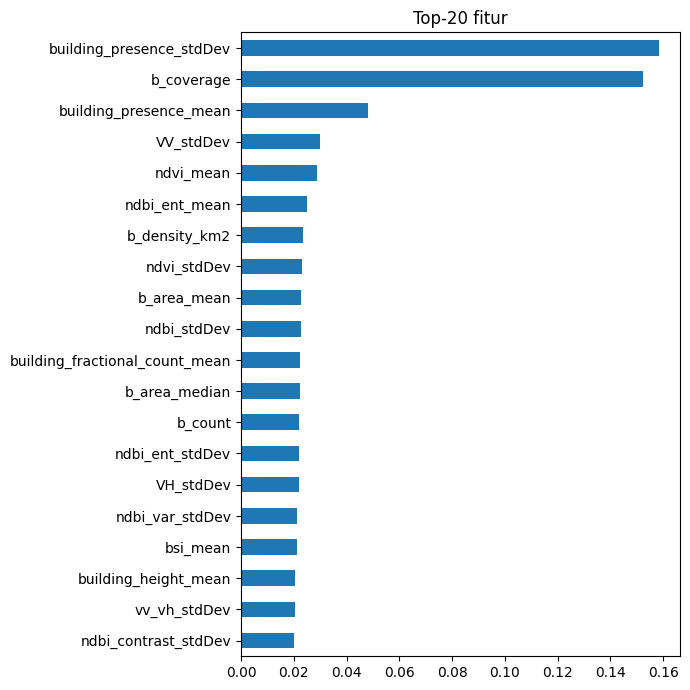

In [23]:
m_full = make_model().fit(X, y)
imp = pd.Series(m_full.feature_importances_, index=feat_cols).sort_values()
imp.tail(20).plot.barh(figsize=(7, 7)); plt.title("Top-20 fitur"); plt.tight_layout()

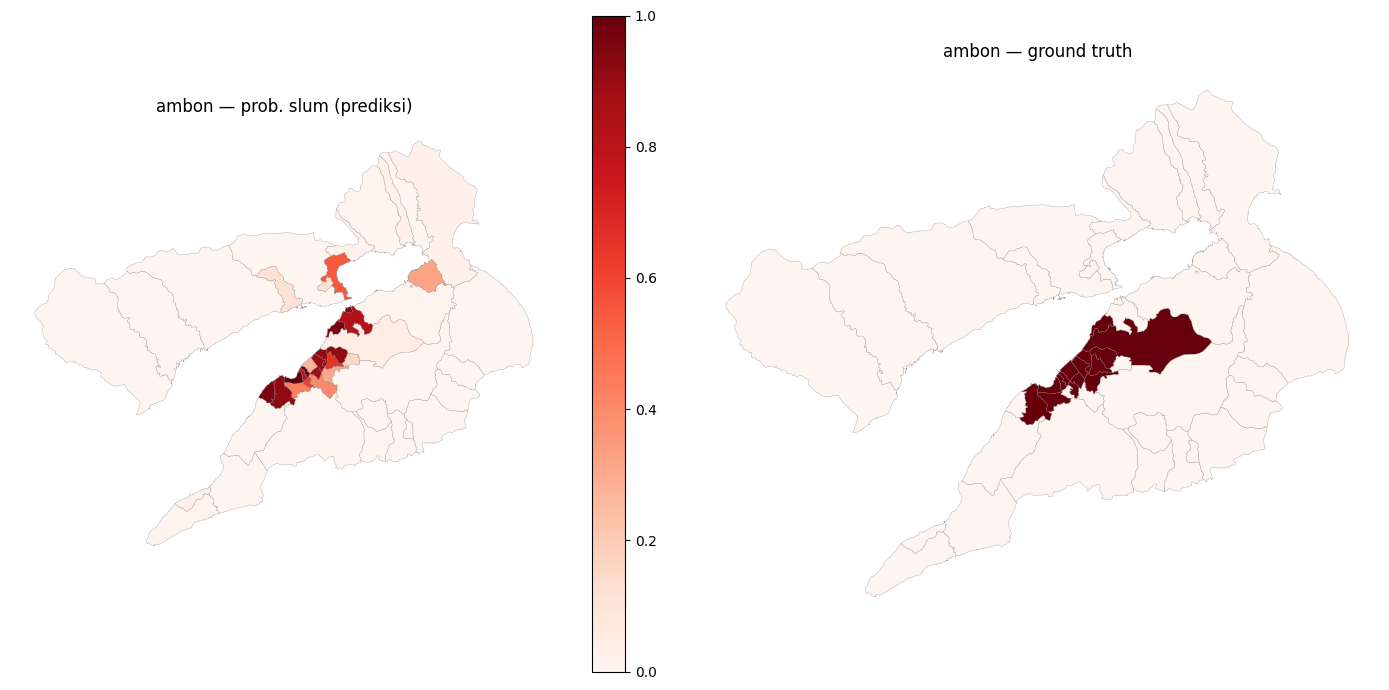

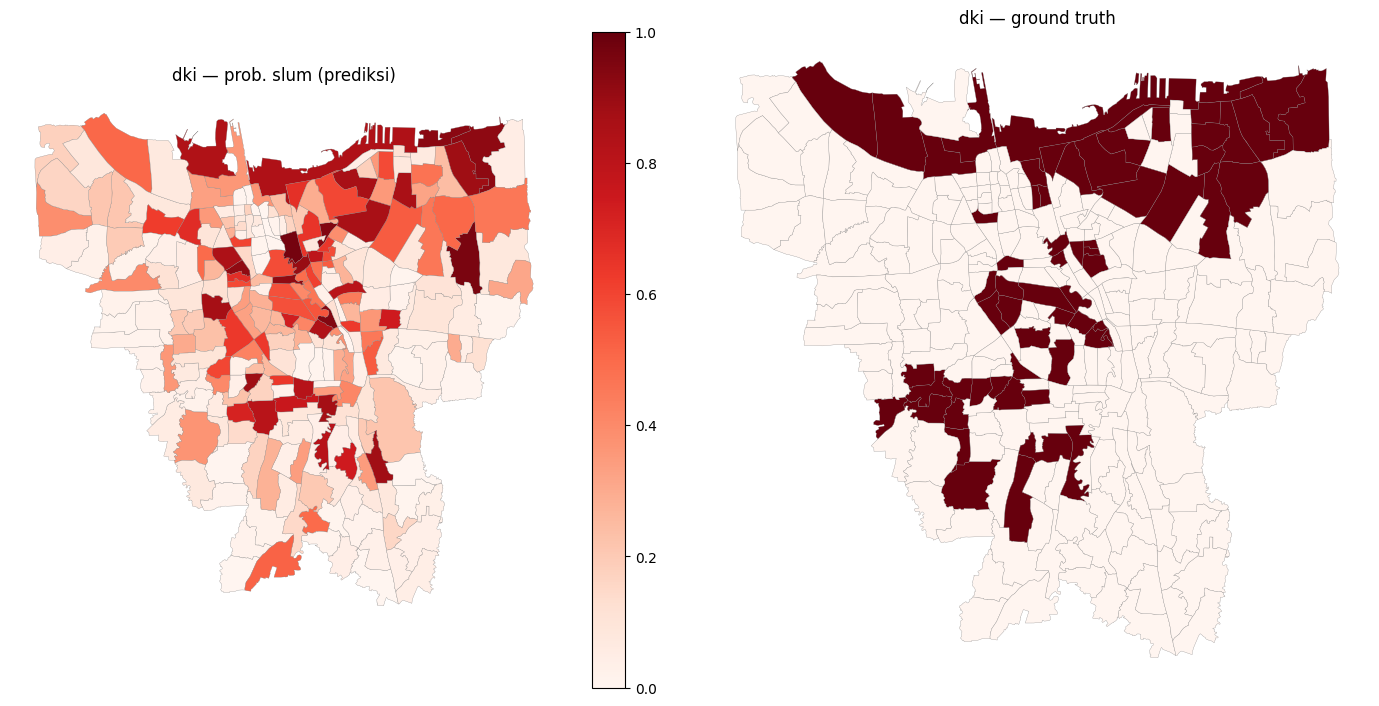

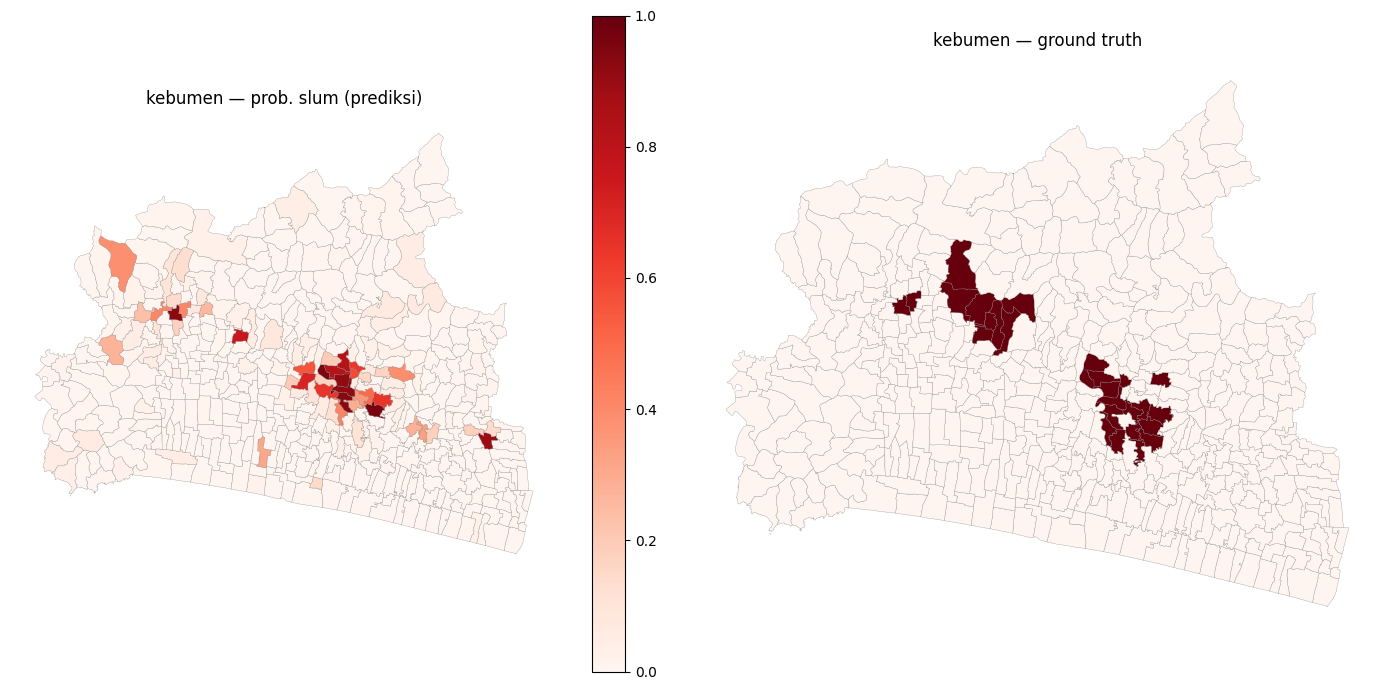

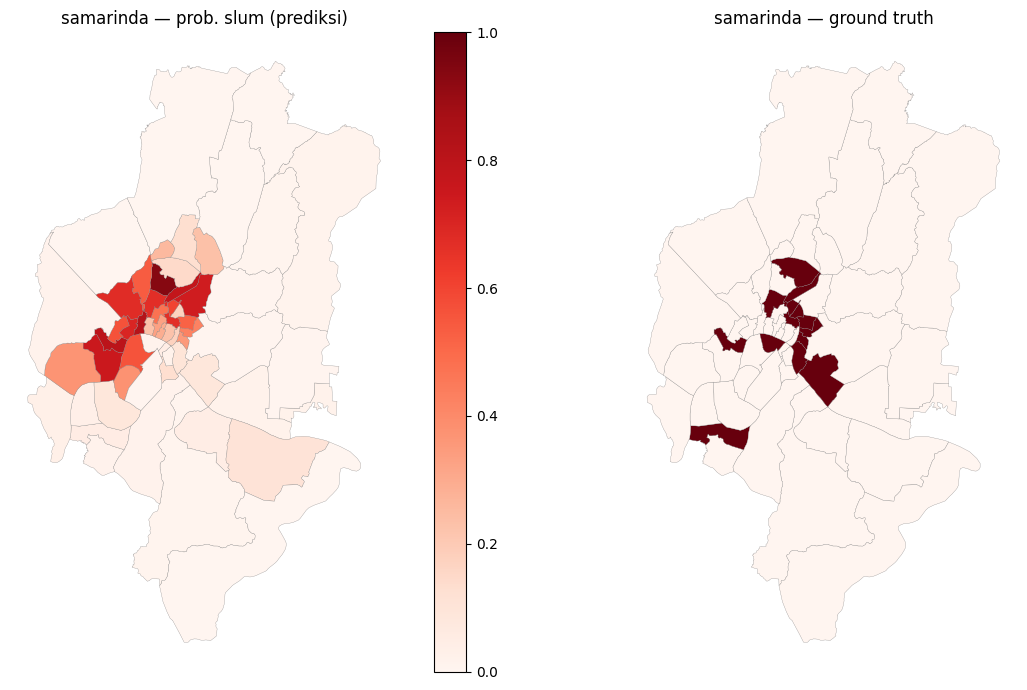

In [24]:
g = gpd.read_file("../data/processed/labels.geojson").to_crs(4326)
g = g.merge(pd.DataFrame({"unit_id": df.unit_id, "city": df.city, "prob": oof}),
            on=["unit_id", "city"], how="left")
for c in sorted(g["city"].unique()):
    s = g[g["city"] == c]
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    s.plot(column="prob", cmap="Reds", legend=True, ax=ax[0],
           vmin=0, vmax=1, edgecolor="grey", linewidth=0.2)
    ax[0].set_title(f"{c} — prob. slum (prediksi)"); ax[0].axis("off")
    s.plot(column="slum", cmap="Reds", ax=ax[1], edgecolor="grey", linewidth=0.2)
    ax[1].set_title(f"{c} — ground truth"); ax[1].axis("off")
    plt.tight_layout(); plt.show()